## Задание

1. Исправить ошибки в реализации Transformer.
2. Придумать свою задачу seq2seq и обучить на ней модель.
3. Сравнить ожидаемые зачения и предсказания модели.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import copy

from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # не была определена переменная device

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [ ]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Исправлен порядок операций
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        # attention не был определен
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))

        # Cross-attention добавлен
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        # Добавлена вторая нормализация
        x = self.norm2(x + self.dropout(attn_output))

        # Feed forward
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout, device):
        super(Transformer, self).__init__()
        self.device = device
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2).to(self.device)
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(2).to(self.device)  # размерность 2, а не 3
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool()
        tgt_mask = tgt_mask & nopeak_mask.to(self.device)

        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        output = self.fc(dec_output)
        return output

In [ ]:
src_vocab_size = 1000
tgt_vocab_size = 2000
d_model = 512
num_heads = 8
num_layers = 6
d_ff = 2048
max_seq_length = 50
dropout = 0.1
device = "cuda"

transformer = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout,  device)
transformer = transformer.to(device)

In [ ]:
from random import randint

In [ ]:
def generate_sample():
    start = randint(1, 500)
    extra = 10

    src = torch.arange(start, start+max_seq_length+extra, dtype=torch.int64)
    trg = src + torch.arange(1, max_seq_length+extra+1, dtype=torch.int64)
    labels = trg[1:]

    return src[:max_seq_length], trg[:max_seq_length], labels[:max_seq_length]

In [ ]:
def generate_batch(batch_size: int = 128):
    src_batch = torch.tensor([], dtype=torch.int64)
    trg_batch = torch.tensor([], dtype=torch.int64)
    labels_batch = torch.tensor([], dtype=torch.int64)

    while src_batch.shape[0] < batch_size:
        src_sample, trg_sample, labels_sample = generate_sample()
        src_batch = torch.cat((src_batch, src_sample.unsqueeze(0)))
        trg_batch = torch.cat((trg_batch, trg_sample.unsqueeze(0)))
        labels_batch = torch.cat((labels_batch, labels_sample.unsqueeze(0)))

    return src_batch, trg_batch, labels_batch

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

transformer.train()
train_loss_history = []

for step in tqdm(range(100)):
    src_batch, trg_batch, labels_batch = generate_batch(64)
    optimizer.zero_grad()
    output = transformer(src_batch.to(device), trg_batch.to(device))
    loss = criterion(output.view(-1, output.size(-1)), labels_batch.to(device).view(-1))
    loss.backward()
    optimizer.step()
    train_loss_history.append(loss.item())
    # print(f"Step: {step+1}, Loss: {loss.item()}")

100%|██████████| 100/100 [00:32<00:00,  3.10it/s]


## Visualize train loss

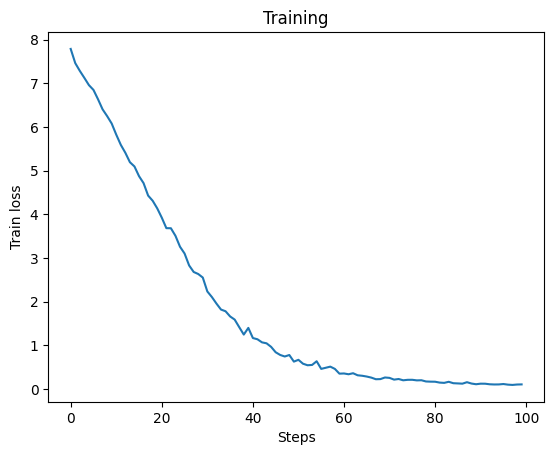

In [ ]:
# Define X and Y variable data
x = np.array(list(range(len(train_loss_history))))
y = np.array(train_loss_history)

plt.plot(x, y)
plt.xlabel("Steps")  # add X-axis label
plt.ylabel("Train loss")  # add Y-axis label
plt.title("Training")  # add title
plt.show()

## Make batches for inference

In [ ]:
transformer.eval()
src_batch, trg_batch, labels_batch = generate_batch(64)

In [ ]:
preds_batch = torch.zeros_like(labels_batch)

In [ ]:
# predict from first token
trg_batch[:,1:] = torch.full(trg_batch[:,1:].shape, 0)

## Inference

In [ ]:
src_batch

tensor([[483, 484, 485,  ..., 530, 531, 532],
        [468, 469, 470,  ..., 515, 516, 517],
        [485, 486, 487,  ..., 532, 533, 534],
        ...,
        [407, 408, 409,  ..., 454, 455, 456],
        [449, 450, 451,  ..., 496, 497, 498],
        [314, 315, 316,  ..., 361, 362, 363]])

In [ ]:
trg_batch

tensor([[484,   0,   0,  ...,   0,   0,   0],
        [469,   0,   0,  ...,   0,   0,   0],
        [486,   0,   0,  ...,   0,   0,   0],
        ...,
        [408,   0,   0,  ...,   0,   0,   0],
        [450,   0,   0,  ...,   0,   0,   0],
        [315,   0,   0,  ...,   0,   0,   0]])

In [ ]:
preds_batch

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

In [ ]:
# generating cycle
for i in range(trg_batch.shape[1]):
    res = transformer(src_batch.to(device), trg_batch.to(device))
    preds_batch[:,i] = res[:,i].argmax(dim=1)

    if i < trg_batch.shape[1]-1:
        trg_batch[:,i+1] = res[:,i].argmax(dim=1)

In [ ]:
preds_batch

tensor([[486, 488, 490,  ..., 580, 582, 584],
        [471, 473, 475,  ..., 565, 567, 569],
        [488, 490, 492,  ..., 582, 584, 586],
        ...,
        [410, 412, 414,  ..., 504, 506, 508],
        [452, 454, 456,  ..., 546, 548, 550],
        [317, 319, 321,  ..., 411, 413, 415]])

In [ ]:
labels_batch

tensor([[486, 488, 490,  ..., 580, 582, 584],
        [471, 473, 475,  ..., 565, 567, 569],
        [488, 490, 492,  ..., 582, 584, 586],
        ...,
        [410, 412, 414,  ..., 504, 506, 508],
        [452, 454, 456,  ..., 546, 548, 550],
        [317, 319, 321,  ..., 411, 413, 415]])

# Исправления в реализации Transformer

1. **DecoderLayer: исправлен порядок вычислений, добавлен cross-attention и определен attention**

2. **EncoderLayer: исправлен порядок операций**  

3. **Добавлена недостающая нормализация**

4. **generate_mask: исправлена размерность маски декодера**

5. **Определена переменная device**

# **Задача:**
# *Преобразование формата дат*


### **Варианты входного формата:**
###   - через тире:  2024-12-25  (год-месяц-день)
###   - через точку:  25.12.2024   (день.месяц.год)
###   - через косую черту: 12/25/2024   (месяц/день/год)

### **Выходной формат:**
###   - "25 декабря 2024"  (день + название месяца в родительном падеже + год)
#
### Модель Transformer обучается преобразовывать любой из трёх входных форматов
### в единый текстовый формат.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        return torch.matmul(attn_probs, V)

    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, _, seq_length, _ = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        return self.W_o(self.combine_heads(attn_output))


In [ ]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()
        self.max_seq_length = max_seq_length
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        seq_len = min(x.size(1), self.max_seq_length)
        return x[:, :seq_len, :] + self.pe[:, :seq_len, :]

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout, device):
        super(Transformer, self).__init__()
        self.device = device
        self.max_seq_length = max_seq_length
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2).to(self.device)
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(2).to(self.device)
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool().to(self.device)
        tgt_mask = tgt_mask & nopeak_mask
        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        return self.fc(dec_output)


In [ ]:
class DateConversionDataset:
    months_ru = {
        1: "января", 2: "февраля", 3: "марта", 4: "апреля",
        5: "мая", 6: "июня", 7: "июля", 8: "августа",
        9: "сентября", 10: "октября", 11: "ноября", 12: "декабря"
    }

    def __init__(self, num_samples=30000, max_len=40):
        self.max_len = max_len
        self.chars = ['0','1','2','3','4','5','6','7','8','9','-','.','/',' '] + \
                     list('абвгдежзийклмнопрстуфхцчшщъыьэюя')
        self.char_to_idx = {ch: i+3 for i, ch in enumerate(self.chars)}
        self.idx_to_char = {i+3: ch for i, ch in enumerate(self.chars)}
        self.char_to_idx['<pad>'] = 0
        self.idx_to_char[0] = '<pad>'
        self.char_to_idx['<start>'] = 1
        self.idx_to_char[1] = '<start>'
        self.char_to_idx['<end>'] = 2
        self.idx_to_char[2] = '<end>'
        self.vocab_size = len(self.chars) + 3

        self.pairs = []
        for _ in range(num_samples):
            year = random.randint(2000, 2025)
            month = random.randint(1, 12)
            day = random.randint(1, 28)

            format_type = random.choice(['iso', 'dot', 'slash'])

            if format_type == 'iso':
                input_date = f"{year}-{month:02d}-{day:02d}"
            elif format_type == 'dot':
                input_date = f"{day}.{month}.{year}"
            else:
                input_date = f"{month}/{day}/{year}"

            output_date = f"{day} {self.months_ru[month]} {year}"
            self.pairs.append((input_date, output_date))

        print(f"generated {len(self.pairs)} date pairs")
        print(f"vocab size: {self.vocab_size}")
        print(f"example: {self.pairs[0][0]} -> {self.pairs[0][1]}")

    def encode_input(self, text):
        indices = [self.char_to_idx.get(ch, 0) for ch in text[:self.max_len]]
        if len(indices) > self.max_len:
            indices = indices[:self.max_len]
        if len(indices) < self.max_len:
            indices += [0] * (self.max_len - len(indices))
        return indices

    def encode_target(self, text):
        indices = [self.char_to_idx['<start>']] + [self.char_to_idx.get(ch, 0) for ch in text] + [self.char_to_idx['<end>']]
        if len(indices) > self.max_len:
            indices = indices[:self.max_len]
        if len(indices) < self.max_len:
            indices += [0] * (self.max_len - len(indices))
        return indices

    def decode(self, indices):
        if torch.is_tensor(indices):
            indices = indices.tolist()
        result = []
        for idx in indices:
            if idx == self.char_to_idx['<end>']:
                break
            if idx in (0, 1):
                continue
            if idx in self.idx_to_char:
                result.append(self.idx_to_char[idx])
        return ''.join(result).strip()

    def get_batch(self, batch_size):
        batch = random.sample(self.pairs, batch_size)
        src_batch = [self.encode_input(src) for src, _ in batch]
        tgt_batch = [self.encode_target(tgt) for _, tgt in batch]
        return torch.tensor(src_batch), torch.tensor(tgt_batch)

In [ ]:
def train(device):
    batch_size = 64
    epochs = 15
    max_len = 40
    dataset = DateConversionDataset(num_samples=30000, max_len=max_len)

    model = Transformer(
        src_vocab_size=dataset.vocab_size,
        tgt_vocab_size=dataset.vocab_size,
        d_model=128,
        num_heads=4,
        num_layers=3,
        d_ff=512,
        max_seq_length=max_len,
        dropout=0.1,
        device=device
    )
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        num_batches = min(200, len(dataset.pairs) // batch_size)

        for _ in tqdm(range(num_batches), desc=f"epoch {epoch+1}/{epochs}"):
            src, tgt = dataset.get_batch(batch_size)
            src, tgt = src.to(device), tgt.to(device)
            tgt_in = tgt[:, :-1]
            tgt_out = tgt[:, 1:]

            optimizer.zero_grad()
            out = model(src, tgt_in)
            loss = criterion(out.reshape(-1, dataset.vocab_size), tgt_out.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / num_batches
        losses.append(avg_loss)
        scheduler.step()
        print(f"epoch {epoch+1}, loss: {avg_loss:.4f}")

    return model, dataset, losses

using device: cuda
generated 30000 date pairs
vocab size: 49
example: 2015-02-12 -> 12 февраля 2015


epoch 1/15: 100%|██████████| 200/200 [00:06<00:00, 32.39it/s]


epoch 1, loss: 0.3789


epoch 2/15: 100%|██████████| 200/200 [00:05<00:00, 39.09it/s]


epoch 2, loss: 0.0153


...

epoch 13, loss: 0.0004


epoch 14/15: 100%|██████████| 200/200 [00:05<00:00, 34.87it/s]


epoch 14, loss: 0.0005


epoch 15/15: 100%|██████████| 200/200 [00:05<00:00, 36.32it/s]


epoch 15, loss: 0.0007


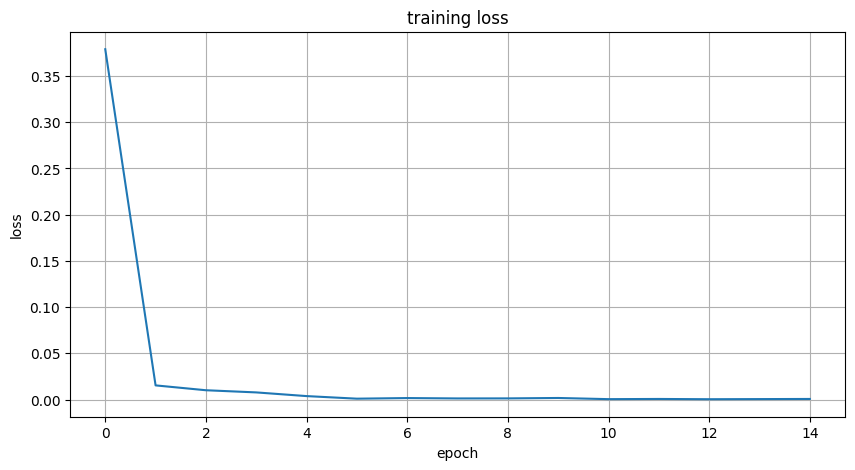


Тестирование:
ok 2024-12-25 - 25 декабря 2024
ok 2023-01-01 - 1 января 2023
ok 25.12.2024 - 25 декабря 2024
ok 1.1.2023 - 1 января 2023
ok 12/25/2024 - 25 декабря 2024
ok 1/1/2023 - 1 января 2023
ok 15.07.2022 - 15 июля 2022
ok 03/08/2025 - 8 марта 2025
ok 2021-09-10 - 10 сентября 2021
Accuracy: 9/9 (100%)

Сравнение результатов:
------------------------------------------------------------
Вход                      ожидаемый результат  Предсказание        
------------------------------------------------------------
2024-12-25                25 декабря 2024      25 декабря 2024     
2023-01-01                1 января 2023        1 января 2023       
25.12.2024                25 декабря 2024      25 декабря 2024     
1.1.2023                  1 января 2023        1 января 2023       
12/25/2024                25 декабря 2024      25 декабря 2024     
1/1/2023                  1 января 2023        1 января 2023       
15.07.2022                15 июля 2022         15 июля 2022        
0

In [ ]:
def test(model, dataset, device):
    model.eval()
    tests = [
        ("2024-12-25", "25 декабря 2024"),
        ("2023-01-01", "1 января 2023"),
        ("25.12.2024", "25 декабря 2024"),
        ("1.1.2023", "1 января 2023"),
        ("12/25/2024", "25 декабря 2024"),
        ("1/1/2023", "1 января 2023"),
        ("15.07.2022", "15 июля 2022"),
        ("03/08/2025", "8 марта 2025"),
        ("2021-09-10", "10 сентября 2021"),
    ]

    print("\nТестирование:")
    correct = 0
    for inp, exp in tests:
        src = torch.tensor([dataset.encode_input(inp)]).to(device)
        gen = generate(model, dataset, src, max_len=len(exp)+5)
        pred = dataset.decode(gen)
        if pred == exp:
            correct += 1
            print(f"ok {inp} - {pred}")
        else:
            print(f"fail {inp} - {pred} (expected: {exp})")

    print(f"Accuracy: {correct}/{len(tests)} ({correct/len(tests)*100:.0f}%)")

    print("\nСравнение результатов:")
    print("-" * 60)
    print(f"{'Вход':<25} {'ожидаемый результат':<20} {'Предсказание':<20}")
    print("-" * 60)
    for inp, exp in tests:
        src = torch.tensor([dataset.encode_input(inp)]).to(device)
        gen = generate(model, dataset, src, max_len=len(exp)+5)
        pred = dataset.decode(gen)
        print(f"{inp:<25} {exp:<20} {pred:<20}")
    print("-" * 60)


if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"using device: {device}")

    model, dataset, losses = train(device)

    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('training loss')
    plt.grid(True)
    plt.show()

    test(model, dataset, device)